# Análise dos Preços de Combustíveis da ANP

## Objetivo

Analisar os preços de revenda dos combustíveis automotivos pesquisados pela ANP, identificando diferenças entre produtos, regiões, estados, municípios, bandeiras e períodos.

## Perguntas de análise

- Qual é o preço médio de cada combustível?
- Como os preços evoluíram ao longo do período?
- Quais estados apresentam os maiores e menores preços médios?
- Quais municípios apresentam maior dispersão de preços?
- Qual é a diferença entre gasolina comum e gasolina aditivada?
- Como os preços variam entre as regiões brasileiras?
- Quantas revendas participaram da pesquisa?
- Como os resultados variam entre as bandeiras?

In [1]:
from pathlib import Path

import pandas as pd

In [2]:
PASTA_PROJETO = Path.cwd().parent
PASTA_PROCESSED = PASTA_PROJETO / "data" / "processed"

ARQUIVO_PROCESSADO = (
    PASTA_PROCESSED
    / "precos_combustiveis_anp_tratado.csv"
)

print("Arquivo:", ARQUIVO_PROCESSADO)
print("Arquivo encontrado:", ARQUIVO_PROCESSADO.exists())

Arquivo: c:\Users\jszq\Documents\GitHub\sales-performance-analytics\data\processed\precos_combustiveis_anp_tratado.csv
Arquivo encontrado: True


In [3]:
df = pd.read_csv(
    ARQUIVO_PROCESSADO,
    sep=";",
    encoding="utf-8-sig",
    parse_dates=["data_da_coleta"]
)

print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

df.head()

Linhas: 422412
Colunas: 18


,regiao__sigla,estado__sigla,municipio,revenda,cnpj_da_revenda,nome_da_rua,numero_rua,complemento,bairro,cep,produto,data_da_coleta,valor_de_venda,unidade_de_medida,bandeira,ano,mes,ano_mes
0,N,AC,CRUZEIRO DO SUL,AMAZONIA COMERCIO DE DERIVADOS DE PETROLEO LTDA,01.492.748/0003-83,AVENIDA COPACABANA,440,NaN,COPACABANA,69980-000,GASOLINA,2026-01-02,7.97,R$ / litro,IPIRANGA,2026,1,2026-01
1,N,AC,CRUZEIRO DO SUL,AMAZONIA COMERCIO DE DERIVADOS DE PETROLEO LTDA,01.492.748/0003-83,AVENIDA COPACABANA,440,NaN,COPACABANA,69980-000,DIESEL,2026-01-02,8.15,R$ / litro,IPIRANGA,2026,1,2026-01
2,N,AC,CRUZEIRO DO SUL,AMAZONIA COMERCIO DE DERIVADOS DE PETROLEO LTDA,01.492.748/0003-83,AVENIDA COPACABANA,440,NaN,COPACABANA,69980-000,DIESEL S10,2026-01-02,8.17,R$ / litro,IPIRANGA,2026,1,2026-01
3,N,AC,RIO BRANCO,AUTO POSTO AMAPA LTDA,00.529.581/0001-53,VIA CHICO MENDES,3570,NaN,AREAL,69906-119,GASOLINA,2026-01-02,7.29,R$ / litro,VIBRA,2026,1,2026-01
4,N,AC,RIO BRANCO,AUTO POSTO AMAPA LTDA,00.529.581/0001-53,VIA CHICO MENDES,3570,NaN,AREAL,69906-119,GASOLINA ADITIVADA,2026-01-02,7.39,R$ / litro,VIBRA,2026,1,2026-01


In [4]:
print("Tipo da data:", df["data_da_coleta"].dtype)
print("Tipo do preço:", df["valor_de_venda"].dtype)

print(
    "Período analisado:",
    df["data_da_coleta"].min().date(),
    "até",
    df["data_da_coleta"].max().date()
)

Tipo da data: datetime64[us]
Tipo do preço: float64
Período analisado: 2026-01-01 até 2026-06-30


In [5]:
print("Total de registros:", len(df))
print("Total de regiões:", df["regiao__sigla"].nunique())
print("Total de estados:", df["estado__sigla"].nunique())
print("Total de municípios:", df["municipio"].nunique())
print("Total de revendas:", df["cnpj_da_revenda"].nunique())
print("Total de bandeiras:", df["bandeira"].nunique())
print("Total de produtos:", df["produto"].nunique())

Total de registros: 422412
Total de regiões: 5
Total de estados: 27
Total de municípios: 416
Total de revendas: 7963
Total de bandeiras: 47
Total de produtos: 6


In [6]:
resumo_executivo = pd.DataFrame({
    "Indicador": [
        "Registros",
        "Regiões",
        "Estados",
        "Municípios",
        "Revendas",
        "Bandeiras",
        "Produtos"
    ],
    "Valor": [
        len(df),
        df["regiao__sigla"].nunique(),
        df["estado__sigla"].nunique(),
        df["municipio"].nunique(),
        df["cnpj_da_revenda"].nunique(),
        df["bandeira"].nunique(),
        df["produto"].nunique()
    ]
})

resumo_executivo

,Indicador,Valor
0,Registros,422412
1,Regiões,5
2,Estados,27
3,Municípios,416
4,Revendas,7963
5,Bandeiras,47
6,Produtos,6


In [7]:
preco_medio_produto = (
    df
    .groupby("produto")["valor_de_venda"]
    .mean()
    .reset_index()
)

preco_medio_produto = (
    preco_medio_produto
    .sort_values(
        by="valor_de_venda",
        ascending=False
    )
)

preco_medio_produto

,produto,valor_de_venda
1,DIESEL S10,6.887459
4,GASOLINA ADITIVADA,6.760228
0,DIESEL,6.760093
3,GASOLINA,6.563049
2,ETANOL,4.709584
5,GNV,4.538153


In [8]:
preco_medio_produto["valor_de_venda"] = (
    preco_medio_produto["valor_de_venda"]
    .round(2)
)

preco_medio_produto

,produto,valor_de_venda
1,DIESEL S10,6.89
4,GASOLINA ADITIVADA,6.76
0,DIESEL,6.76
3,GASOLINA,6.56
2,ETANOL,4.71
5,GNV,4.54


## Análise estadual da Gasolina

Nesta análise, foi considerada exclusivamente a Gasolina Comum. O preço médio estadual representa a média dos registros de preços encontrados na base da ANP, sem ponderação por volume comercializado.

In [9]:
df_gasolina = df[
    df["produto"] == "GASOLINA"
].copy()

print("Registros de Gasolina:", len(df_gasolina))
print("Estados analisados:", df_gasolina["estado__sigla"].nunique())
print(
    "Revendas analisadas:",
    df_gasolina["cnpj_da_revenda"].nunique()
)

Registros de Gasolina: 110923
Estados analisados: 27
Revendas analisadas: 7899


In [10]:
gasolina_por_estado = (
    df_gasolina
    .groupby("estado__sigla")
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        preco_mediano=("valor_de_venda", "median"),
        preco_minimo=("valor_de_venda", "min"),
        preco_maximo=("valor_de_venda", "max"),
        desvio_padrao=("valor_de_venda", "std"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique")
    )
    .reset_index()
)

colunas_valores = [
    "preco_medio",
    "preco_mediano",
    "preco_minimo",
    "preco_maximo",
    "desvio_padrao"
]

gasolina_por_estado[colunas_valores] = (
    gasolina_por_estado[colunas_valores].round(2)
)

gasolina_por_estado.head()

,estado__sigla,preco_medio,preco_mediano,preco_minimo,preco_maximo,desvio_padrao,quantidade_registros,quantidade_revendas
0,AC,7.48,7.39,6.79,8.50,0.40,299,20
1,AL,6.68,6.74,5.44,7.67,0.45,1493,102
2,AM,7.31,6.99,6.48,9.29,0.64,1383,92
3,AP,6.44,6.43,5.95,7.55,0.24,239,37
4,BA,7.02,6.99,5.74,8.88,0.51,5789,299


In [11]:
top_5_estados_gasolina = (
    gasolina_por_estado
    .sort_values(
        by="preco_medio",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

top_5_estados_gasolina

,estado__sigla,preco_medio,preco_mediano,preco_minimo,preco_maximo,desvio_padrao,quantidade_registros,quantidade_revendas
0,AC,7.48,7.39,6.79,8.50,0.40,299,20
1,RR,7.44,7.69,6.70,7.90,0.40,350,16
2,AM,7.31,6.99,6.48,9.29,0.64,1383,92
3,RO,7.21,7.27,6.48,7.99,0.28,1278,75
4,BA,7.02,6.99,5.74,8.88,0.51,5789,299


In [12]:
bottom_5_estados_gasolina = (
    gasolina_por_estado
    .sort_values(
        by="preco_medio",
        ascending=True
    )
    .head(5)
    .reset_index(drop=True)
)

bottom_5_estados_gasolina

,estado__sigla,preco_medio,preco_mediano,preco_minimo,preco_maximo,desvio_padrao,quantidade_registros,quantidade_revendas
0,PB,6.34,6.39,5.39,7.19,0.30,1672,133
1,MG,6.34,6.34,5.29,7.39,0.28,11928,752
2,PI,6.40,6.48,5.65,7.69,0.41,1388,104
3,SP,6.42,6.39,5.09,9.79,0.39,30913,2579
4,DF,6.43,6.47,5.70,6.97,0.20,1247,134


In [13]:
gasolina_por_estado_preciso = (
    df_gasolina
    .groupby("estado__sigla", as_index=False)
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique")
    )
)

estado_maior_preco = (
    gasolina_por_estado_preciso
    .sort_values("preco_medio", ascending=False)
    .iloc[0]
)

estado_menor_preco = (
    gasolina_por_estado_preciso
    .sort_values("preco_medio", ascending=True)
    .iloc[0]
)

diferenca_absoluta = (
    estado_maior_preco["preco_medio"]
    - estado_menor_preco["preco_medio"]
)

diferenca_percentual = (
    diferenca_absoluta
    / estado_menor_preco["preco_medio"]
    * 100
)

print(
    "Estado com maior preço médio:",
    estado_maior_preco["estado__sigla"]
)

print(
    "Preço médio mais alto:",
    round(estado_maior_preco["preco_medio"], 2)
)

print(
    "Estado com menor preço médio:",
    estado_menor_preco["estado__sigla"]
)

print(
    "Preço médio mais baixo:",
    round(estado_menor_preco["preco_medio"], 2)
)

print(
    "Diferença absoluta:",
    round(diferenca_absoluta, 2)
)

print(
    "Diferença percentual:",
    round(diferenca_percentual, 2),
    "%"
)

Estado com maior preço médio: AC
Preço médio mais alto: 7.48
Estado com menor preço médio: MG
Preço médio mais baixo: 6.34
Diferença absoluta: 1.14
Diferença percentual: 18.04 %


In [14]:
comparacao_extremos_gasolina = pd.DataFrame({
    "indicador": [
        "Estado com maior preço médio",
        "Maior preço médio observado",
        "Estado com menor preço médio",
        "Menor preço médio observado",
        "Diferença absoluta",
        "Diferença percentual"
    ],
    "valor": [
        estado_maior_preco["estado__sigla"],
        round(estado_maior_preco["preco_medio"], 2),
        estado_menor_preco["estado__sigla"],
        round(estado_menor_preco["preco_medio"], 2),
        round(diferenca_absoluta, 2),
        f"{diferenca_percentual:.2f}%"
    ]
})

comparacao_extremos_gasolina

,indicador,valor
0,Estado com maior preço médio,AC
1,Maior preço médio observado,7.48
2,Estado com menor preço médio,MG
3,Menor preço médio observado,6.34
4,Diferença absoluta,1.14
5,Diferença percentual,18.04%


### Insight sobre a diferença estadual

No primeiro semestre de 2026, o estado com o maior preço médio observado de Gasolina Comum foi o **Acre**, com aproximadamente **R$ 7,48 por litro**.

O menor preço médio observado foi registrado em **Minas Gerais**, com aproximadamente **R$ 6,34 por litro**.

A diferença entre os extremos foi de aproximadamente **R$ 1,14 por litro**, equivalente a **18,04%** sobre o menor preço médio.

Embora Paraíba e Minas Gerais apresentem R$ 6,34 quando os valores são arredondados para duas casas decimais, Minas Gerais possui a menor média quando são consideradas todas as casas decimais do cálculo.

Os resultados representam médias dos preços encontrados nos registros da pesquisa da ANP, sem ponderação por volume comercializado. A quantidade de estabelecimentos e observações varia entre os estados.

## Evolução mensal da Gasolina

Esta análise apresenta a evolução do preço médio observado da Gasolina Comum entre janeiro e junho de 2026.

As médias são calculadas a partir dos registros individuais disponíveis na pesquisa da ANP e não representam ponderação por volume comercializado.

In [15]:
gasolina_mensal = (
    df_gasolina
    .groupby(["ano", "mes"])
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        preco_mediano=("valor_de_venda", "median"),
        preco_minimo=("valor_de_venda", "min"),
        preco_maximo=("valor_de_venda", "max"),
        desvio_padrao=("valor_de_venda", "std"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique")
    )
    .reset_index()
    .sort_values(["ano", "mes"])
)

gasolina_mensal["mes_nome"] = gasolina_mensal["mes"].map({
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
})

colunas_precos = [
    "preco_medio",
    "preco_mediano",
    "preco_minimo",
    "preco_maximo",
    "desvio_padrao"
]

gasolina_mensal[colunas_precos] = (
    gasolina_mensal[colunas_precos].round(3)
)

gasolina_mensal[[
    "ano",
    "mes",
    "mes_nome",
    "preco_medio",
    "preco_mediano",
    "preco_minimo",
    "preco_maximo",
    "desvio_padrao",
    "quantidade_registros",
    "quantidade_revendas"
]]

,ano,mes,mes_nome,preco_medio,preco_mediano,preco_minimo,preco_maximo,desvio_padrao,quantidade_registros,quantidade_revendas
0,2026,1,Janeiro,6.326,6.29,5.09,9.29,0.362,17221,5659
1,2026,2,Fevereiro,6.312,6.29,5.28,9.29,0.362,17092,5970
2,2026,3,Março,6.603,6.59,5.29,9.54,0.434,20349,5758
3,2026,4,Abril,6.762,6.69,5.59,9.59,0.391,18406,5934
4,2026,5,Maio,6.678,6.59,5.49,9.69,0.401,17465,5928
5,2026,6,Junho,6.657,6.59,5.49,9.79,0.397,20390,5718


In [16]:
gasolina_mensal["variacao_mensal_percentual"] = (
    gasolina_mensal["preco_medio"]
    .pct_change()
    .mul(100)
    .round(2)
)

gasolina_mensal[[
    "mes_nome",
    "preco_medio",
    "variacao_mensal_percentual",
    "quantidade_registros",
    "quantidade_revendas"
]]

,mes_nome,preco_medio,variacao_mensal_percentual,quantidade_registros,quantidade_revendas
0,Janeiro,6.326,NaN,17221,5659
1,Fevereiro,6.312,-0.22,17092,5970
2,Março,6.603,4.61,20349,5758
3,Abril,6.762,2.41,18406,5934
4,Maio,6.678,-1.24,17465,5928
5,Junho,6.657,-0.31,20390,5718


In [17]:
preco_janeiro = gasolina_mensal.iloc[0]["preco_medio"]
preco_junho = gasolina_mensal.iloc[-1]["preco_medio"]

variacao_absoluta_semestre = preco_junho - preco_janeiro

variacao_percentual_semestre = (
    variacao_absoluta_semestre
    / preco_janeiro
    * 100
)

print("Preço médio observado em janeiro:", round(preco_janeiro, 3))
print("Preço médio observado em junho:", round(preco_junho, 3))
print(
    "Variação absoluta de janeiro a junho:",
    round(variacao_absoluta_semestre, 3)
)
print(
    "Variação percentual de janeiro a junho:",
    round(variacao_percentual_semestre, 2),
    "%"
)

Preço médio observado em janeiro: 6.326
Preço médio observado em junho: 6.657
Variação absoluta de janeiro a junho: 0.331
Variação percentual de janeiro a junho: 5.23 %


### Insight sobre a evolução mensal

O preço médio observado da Gasolina Comum iniciou o primeiro semestre de 2026 em aproximadamente **R$ 6,326 por litro** e encerrou junho em aproximadamente **R$ 6,657 por litro**.

A variação acumulada entre janeiro e junho foi de aproximadamente **R$ 0,331 por litro**, equivalente a um aumento de **5,23%**.

O maior aumento mensal ocorreu em março, quando o preço médio observado avançou **4,61%** em relação a fevereiro. O maior preço médio do período foi registrado em abril, com aproximadamente **R$ 6,762 por litro**.

Após o pico de abril, foram observadas pequenas reduções em maio e junho. Mesmo com essa desaceleração, o preço médio de junho permaneceu acima do valor observado no início do semestre.

A quantidade mensal de registros permaneceu entre aproximadamente 17 mil e 20 mil observações, com mais de 5,6 mil revendas distintas em todos os meses. Essa cobertura contribui para a consistência da comparação ao longo do período.

Os valores representam médias dos registros disponíveis na pesquisa da ANP, sem ponderação por volume comercializado.

In [18]:
gasolina_mensal_grafico = (
    df_gasolina
    .groupby(["ano", "mes"], as_index=False)
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique")
    )
    .sort_values(["ano", "mes"])
)

gasolina_mensal_grafico["mes_nome"] = (
    gasolina_mensal_grafico["mes"].map({
        1: "Jan",
        2: "Fev",
        3: "Mar",
        4: "Abr",
        5: "Mai",
        6: "Jun",
        7: "Jul",
        8: "Ago",
        9: "Set",
        10: "Out",
        11: "Nov",
        12: "Dez"
    })
)

gasolina_mensal_grafico[[
    "mes_nome",
    "preco_medio",
    "quantidade_registros",
    "quantidade_revendas"
]]

,mes_nome,preco_medio,quantidade_registros,quantidade_revendas
0,Jan,6.325559,17221,5659
1,Fev,6.311667,17092,5970
2,Mar,6.602842,20349,5758
3,Abr,6.762000,18406,5934
4,Mai,6.677873,17465,5928
5,Jun,6.656689,20390,5718


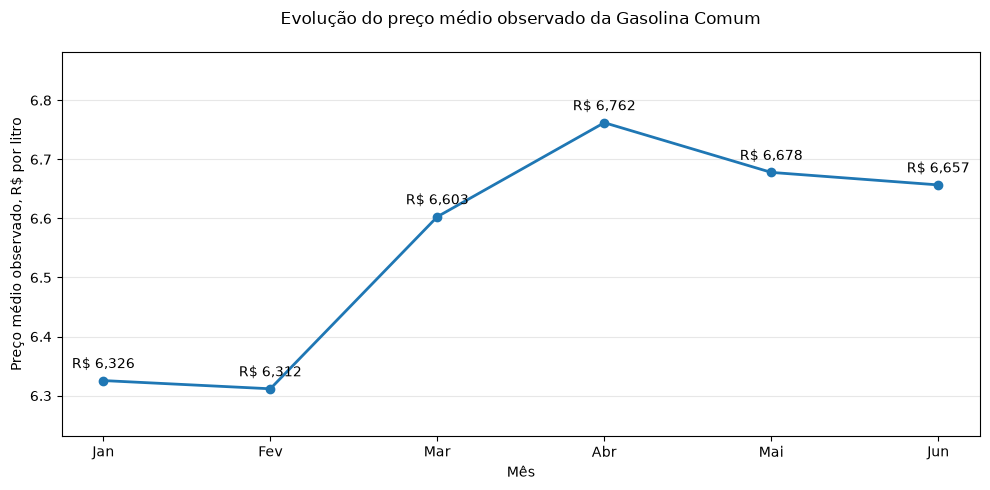

Gráfico salvo em:
c:\Users\jszq\Documents\GitHub\sales-performance-analytics\images\evolucao_mensal_gasolina_2026.png
Arquivo encontrado: True


In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    gasolina_mensal_grafico["mes_nome"],
    gasolina_mensal_grafico["preco_medio"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Evolução do preço médio observado da Gasolina Comum",
    pad=20
)

ax.set_xlabel("Mês")
ax.set_ylabel("Preço médio observado, R$ por litro")

ax.grid(
    axis="y",
    alpha=0.3
)

# Criar espaço adicional acima e abaixo da série
preco_minimo_grafico = gasolina_mensal_grafico["preco_medio"].min()
preco_maximo_grafico = gasolina_mensal_grafico["preco_medio"].max()

ax.set_ylim(
    preco_minimo_grafico - 0.08,
    preco_maximo_grafico + 0.12
)

for mes, preco in zip(
    gasolina_mensal_grafico["mes_nome"],
    gasolina_mensal_grafico["preco_medio"]
):
    ax.annotate(
        f"R$ {preco:.3f}".replace(".", ","),
        (mes, preco),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center"
    )

plt.tight_layout()

ARQUIVO_GRAFICO = (
    PASTA_PROJETO
    / "images"
    / "evolucao_mensal_gasolina_2026.png"
)

fig.savefig(
    ARQUIVO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico salvo em:")
print(ARQUIVO_GRAFICO)
print("Arquivo encontrado:", ARQUIVO_GRAFICO.exists())

## Comparação entre Gasolina e Etanol

Esta análise compara os preços médios observados da Gasolina Comum e do Etanol no primeiro semestre de 2026.

Também será calculada a relação percentual entre o preço médio do Etanol e o preço médio da Gasolina em cada mês.

Os resultados representam médias dos registros disponíveis na pesquisa da ANP, sem ponderação por volume comercializado.

In [21]:
df_gasolina_etanol = df[
    df["produto"].isin([
        "GASOLINA",
        "ETANOL"
    ])
].copy()

print(
    df_gasolina_etanol["produto"]
    .value_counts()
)

produto
GASOLINA    110923
ETANOL       93891
Name: count, dtype: int64


In [22]:
comparacao_mensal = (
    df_gasolina_etanol
    .groupby(
        ["ano", "mes", "produto"],
        as_index=False
    )
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        preco_mediano=("valor_de_venda", "median"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique")
    )
    .sort_values(
        ["ano", "mes", "produto"]
    )
)

comparacao_mensal["mes_nome"] = (
    comparacao_mensal["mes"].map({
        1: "Jan",
        2: "Fev",
        3: "Mar",
        4: "Abr",
        5: "Mai",
        6: "Jun",
        7: "Jul",
        8: "Ago",
        9: "Set",
        10: "Out",
        11: "Nov",
        12: "Dez"
    })
)

comparacao_mensal_exibicao = (
    comparacao_mensal.copy()
)

comparacao_mensal_exibicao[
    ["preco_medio", "preco_mediano"]
] = (
    comparacao_mensal_exibicao[
        ["preco_medio", "preco_mediano"]
    ]
    .round(3)
)

comparacao_mensal_exibicao[[
    "mes",
    "mes_nome",
    "produto",
    "preco_medio",
    "preco_mediano",
    "quantidade_registros",
    "quantidade_revendas"
]]

,mes,mes_nome,produto,preco_medio,preco_mediano,quantidade_registros,quantidade_revendas
0,1,Jan,ETANOL,4.709,4.69,14504,4839
1,1,Jan,GASOLINA,6.326,6.29,17221,5659
2,2,Fev,ETANOL,4.768,4.75,14452,5148
3,2,Fev,GASOLINA,6.312,6.29,17092,5970
4,3,Mar,ETANOL,4.864,4.80,17191,4944
5,3,Mar,GASOLINA,6.603,6.59,20349,5758
6,4,Abr,ETANOL,4.868,4.85,15634,5136
7,4,Abr,GASOLINA,6.762,6.69,18406,5934
8,5,Mai,ETANOL,4.613,4.59,14767,5073
9,5,Mai,GASOLINA,6.678,6.59,17465,5928


In [23]:
precos_gasolina_etanol = (
    comparacao_mensal
    .pivot(
        index=["ano", "mes", "mes_nome"],
        columns="produto",
        values="preco_medio"
    )
    .reset_index()
    .sort_values(["ano", "mes"])
)

precos_gasolina_etanol.columns.name = None

precos_gasolina_etanol = (
    precos_gasolina_etanol.rename(
        columns={
            "GASOLINA": "preco_gasolina",
            "ETANOL": "preco_etanol"
        }
    )
)

precos_gasolina_etanol[
    "relacao_etanol_gasolina"
] = (
    precos_gasolina_etanol["preco_etanol"]
    / precos_gasolina_etanol["preco_gasolina"]
)

precos_gasolina_etanol[
    "relacao_percentual"
] = (
    precos_gasolina_etanol[
        "relacao_etanol_gasolina"
    ]
    .mul(100)
)

precos_gasolina_etanol_exibicao = (
    precos_gasolina_etanol.copy()
)

precos_gasolina_etanol_exibicao[
    "preco_gasolina"
] = (
    precos_gasolina_etanol_exibicao[
        "preco_gasolina"
    ]
    .round(3)
)

precos_gasolina_etanol_exibicao[
    "preco_etanol"
] = (
    precos_gasolina_etanol_exibicao[
        "preco_etanol"
    ]
    .round(3)
)

precos_gasolina_etanol_exibicao[
    "relacao_percentual"
] = (
    precos_gasolina_etanol_exibicao[
        "relacao_percentual"
    ]
    .round(2)
)

precos_gasolina_etanol_exibicao[[
    "mes_nome",
    "preco_gasolina",
    "preco_etanol",
    "relacao_percentual"
]]

,mes_nome,preco_gasolina,preco_etanol,relacao_percentual
0,Jan,6.326,4.709,74.44
1,Fev,6.312,4.768,75.55
2,Mar,6.603,4.864,73.67
3,Abr,6.762,4.868,71.99
4,Mai,6.678,4.613,69.08
5,Jun,6.657,4.447,66.81


In [24]:
maior_relacao = (
    precos_gasolina_etanol
    .sort_values(
        "relacao_percentual",
        ascending=False
    )
    .iloc[0]
)

menor_relacao = (
    precos_gasolina_etanol
    .sort_values(
        "relacao_percentual",
        ascending=True
    )
    .iloc[0]
)

variacao_relacao_extremos = (
    menor_relacao["relacao_percentual"]
    - maior_relacao["relacao_percentual"]
)

print(
    "Mês com maior relação:",
    maior_relacao["mes_nome"]
)

print(
    "Maior relação:",
    round(maior_relacao["relacao_percentual"], 2),
    "%"
)

print(
    "Mês com menor relação:",
    menor_relacao["mes_nome"]
)

print(
    "Menor relação:",
    round(menor_relacao["relacao_percentual"], 2),
    "%"
)

print(
    "Diferença entre maior e menor relação:",
    round(abs(variacao_relacao_extremos), 2),
    "pontos percentuais"
)

Mês com maior relação: Fev
Maior relação: 75.55 %
Mês com menor relação: Jun
Menor relação: 66.81 %
Diferença entre maior e menor relação: 8.74 pontos percentuais


In [26]:
primeiro_mes = precos_gasolina_etanol.iloc[0]
ultimo_mes = precos_gasolina_etanol.iloc[-1]

variacao_gasolina = (
    ultimo_mes["preco_gasolina"]
    / primeiro_mes["preco_gasolina"]
    - 1
) * 100

variacao_etanol = (
    ultimo_mes["preco_etanol"]
    / primeiro_mes["preco_etanol"]
    - 1
) * 100

variacao_relacao = (
    ultimo_mes["relacao_percentual"]
    - primeiro_mes["relacao_percentual"]
)

print(
    "Variação da Gasolina entre janeiro e junho:",
    round(variacao_gasolina, 2),
    "%"
)

print(
    "Variação do Etanol entre janeiro e junho:",
    round(variacao_etanol, 2),
    "%"
)

print(
    "Variação da relação entre janeiro e junho:",
    round(variacao_relacao, 2),
    "pontos percentuais"
)

Variação da Gasolina entre janeiro e junho: 5.23 %
Variação do Etanol entre janeiro e junho: -5.56 %
Variação da relação entre janeiro e junho: -7.63 pontos percentuais


### Insight sobre a relação entre Etanol e Gasolina

A relação entre o preço médio observado do Etanol e o preço médio observado da Gasolina atingiu o maior valor em **fevereiro**, quando o preço do Etanol correspondeu a aproximadamente **75,55%** do preço da Gasolina.

A menor relação foi observada em **junho**, com aproximadamente **66,81%**, representando uma diferença de **8,74 pontos percentuais** em comparação com o maior resultado do semestre.

Entre janeiro e junho, o preço médio observado da Gasolina aumentou aproximadamente **5,23%**, enquanto o preço médio observado do Etanol apresentou redução de aproximadamente **5,56%**. Como resultado, a relação entre os preços caiu de **74,44% para 66,81%**.

Essa redução indica que o Etanol ficou relativamente mais barato em comparação com a Gasolina ao longo do semestre. Entretanto, o indicador representa uma comparação agregada dos preços médios observados na pesquisa da ANP e não considera o consumo específico de cada veículo, condições de uso ou correspondência exata entre os estabelecimentos pesquisados.

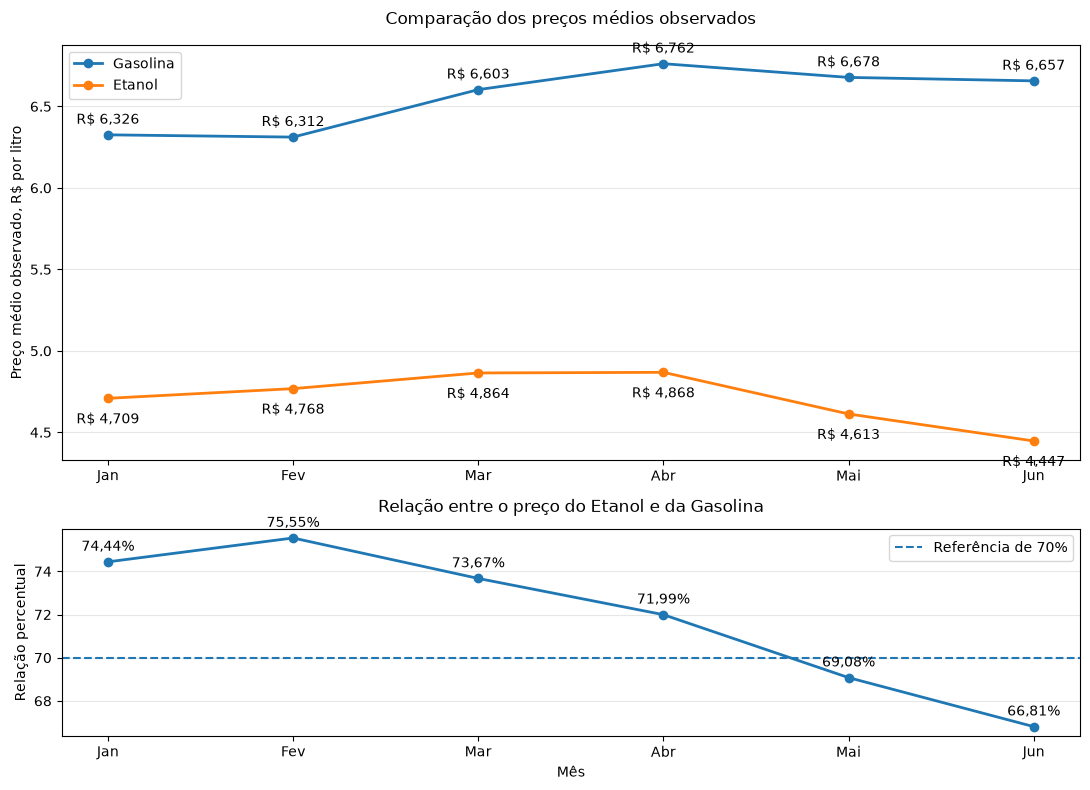

Gráfico salvo em:
c:\Users\jszq\Documents\GitHub\sales-performance-analytics\images\comparacao_gasolina_etanol_2026.png
Arquivo encontrado: True


In [27]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 8),
    gridspec_kw={
        "height_ratios": [2, 1]
    }
)

# Painel 1: preços médios

ax1.plot(
    precos_gasolina_etanol["mes_nome"],
    precos_gasolina_etanol["preco_gasolina"],
    marker="o",
    linewidth=2,
    label="Gasolina"
)

ax1.plot(
    precos_gasolina_etanol["mes_nome"],
    precos_gasolina_etanol["preco_etanol"],
    marker="o",
    linewidth=2,
    label="Etanol"
)

ax1.set_title(
    "Comparação dos preços médios observados",
    pad=15
)

ax1.set_ylabel("Preço médio observado, R$ por litro")

ax1.grid(
    axis="y",
    alpha=0.3
)

ax1.legend()

# Rótulos da Gasolina

for mes, preco in zip(
    precos_gasolina_etanol["mes_nome"],
    precos_gasolina_etanol["preco_gasolina"]
):
    ax1.annotate(
        f"R$ {preco:.3f}".replace(".", ","),
        (mes, preco),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

# Rótulos do Etanol

for mes, preco in zip(
    precos_gasolina_etanol["mes_nome"],
    precos_gasolina_etanol["preco_etanol"]
):
    ax1.annotate(
        f"R$ {preco:.3f}".replace(".", ","),
        (mes, preco),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center"
    )

# Painel 2: relação percentual

ax2.plot(
    precos_gasolina_etanol["mes_nome"],
    precos_gasolina_etanol["relacao_percentual"],
    marker="o",
    linewidth=2
)

ax2.axhline(
    y=70,
    linestyle="--",
    linewidth=1.5,
    label="Referência de 70%"
)

ax2.set_title(
    "Relação entre o preço do Etanol e da Gasolina",
    pad=12
)

ax2.set_xlabel("Mês")
ax2.set_ylabel("Relação percentual")

ax2.grid(
    axis="y",
    alpha=0.3
)

ax2.legend()

for mes, relacao in zip(
    precos_gasolina_etanol["mes_nome"],
    precos_gasolina_etanol["relacao_percentual"]
):
    ax2.annotate(
        f"{relacao:.2f}%".replace(".", ","),
        (mes, relacao),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.tight_layout()

ARQUIVO_GRAFICO_COMPARACAO = (
    PASTA_PROJETO
    / "images"
    / "comparacao_gasolina_etanol_2026.png"
)

fig.savefig(
    ARQUIVO_GRAFICO_COMPARACAO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico salvo em:")
print(ARQUIVO_GRAFICO_COMPARACAO)
print(
    "Arquivo encontrado:",
    ARQUIVO_GRAFICO_COMPARACAO.exists()
)

## Análise regional da Gasolina

Esta análise compara o preço da Gasolina Comum entre as cinco regiões brasileiras durante o primeiro semestre de 2026.

Além do preço médio observado, serão avaliados a mediana, os preços mínimo e máximo, a dispersão, a quantidade de registros e a quantidade de revendas pesquisadas.

Os resultados são calculados a partir dos registros disponíveis na base da ANP, sem ponderação por volume comercializado.

In [31]:
gasolina_por_regiao = (
    df_gasolina
    .groupby("regiao__sigla")
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        preco_mediano=("valor_de_venda", "median"),
        preco_minimo=("valor_de_venda", "min"),
        preco_maximo=("valor_de_venda", "max"),
        desvio_padrao=("valor_de_venda", "std"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique"),
        quantidade_estados=("estado__sigla", "nunique")
    )
    .reset_index()
)

nomes_regioes = {
    "N": "Norte",
    "NE": "Nordeste",
    "CO": "Centro-Oeste",
    "SE": "Sudeste",
    "S": "Sul"
}

gasolina_por_regiao["regiao"] = (
    gasolina_por_regiao["regiao__sigla"]
    .map(nomes_regioes)
)

gasolina_por_regiao = (
    gasolina_por_regiao
    .sort_values(
        by="preco_medio",
        ascending=False
    )
    .reset_index(drop=True)
)

colunas_precos_regiao = [
    "preco_medio",
    "preco_mediano",
    "preco_minimo",
    "preco_maximo",
    "desvio_padrao"
]

gasolina_por_regiao[colunas_precos_regiao] = (
    gasolina_por_regiao[colunas_precos_regiao]
    .round(3)
)

gasolina_por_regiao[[
    "regiao",
    "preco_medio",
    "preco_mediano",
    "preco_minimo",
    "preco_maximo",
    "desvio_padrao",
    "quantidade_registros",
    "quantidade_revendas",
    "quantidade_estados"
]]

,regiao,preco_medio,preco_mediano,preco_minimo,preco_maximo,desvio_padrao,quantidade_registros,quantidade_revendas,quantidade_estados
0,Norte,7.009,6.99,5.33,9.29,0.538,6907,475,7
1,Nordeste,6.761,6.76,5.09,8.88,0.488,22846,1474,9
2,Sul,6.554,6.54,5.39,7.99,0.300,19326,1296,3
3,Centro-Oeste,6.540,6.54,5.39,7.55,0.310,8777,663,4
4,Sudeste,6.427,6.39,5.09,9.79,0.366,53067,3991,4


In [33]:
total_registros_regionais = (
    gasolina_por_regiao["quantidade_registros"]
    .sum()
)

print(
    "Total de registros nas regiões:",
    total_registros_regionais
)

print(
    "Total de registros de Gasolina:",
    len(df_gasolina)
)

print(
    "Totais são iguais:",
    total_registros_regionais == len(df_gasolina)
)

Total de registros nas regiões: 110923
Total de registros de Gasolina: 110923
Totais são iguais: True


In [34]:
gasolina_por_regiao_preciso = (
    df_gasolina
    .groupby("regiao__sigla", as_index=False)
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        desvio_padrao=("valor_de_venda", "std"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique")
    )
)

gasolina_por_regiao_preciso["regiao"] = (
    gasolina_por_regiao_preciso["regiao__sigla"]
    .map(nomes_regioes)
)

regiao_maior_preco = (
    gasolina_por_regiao_preciso
    .sort_values(
        "preco_medio",
        ascending=False
    )
    .iloc[0]
)

regiao_menor_preco = (
    gasolina_por_regiao_preciso
    .sort_values(
        "preco_medio",
        ascending=True
    )
    .iloc[0]
)

diferenca_regional_absoluta = (
    regiao_maior_preco["preco_medio"]
    - regiao_menor_preco["preco_medio"]
)

diferenca_regional_percentual = (
    diferenca_regional_absoluta
    / regiao_menor_preco["preco_medio"]
    * 100
)

print(
    "Região com maior preço médio:",
    regiao_maior_preco["regiao"]
)

print(
    "Maior preço médio:",
    round(regiao_maior_preco["preco_medio"], 3)
)

print(
    "Região com menor preço médio:",
    regiao_menor_preco["regiao"]
)

print(
    "Menor preço médio:",
    round(regiao_menor_preco["preco_medio"], 3)
)

print(
    "Diferença absoluta:",
    round(diferenca_regional_absoluta, 3)
)

print(
    "Diferença percentual:",
    round(diferenca_regional_percentual, 2),
    "%"
)

Região com maior preço médio: Norte
Maior preço médio: 7.009
Região com menor preço médio: Sudeste
Menor preço médio: 6.427
Diferença absoluta: 0.582
Diferença percentual: 9.06 %


In [35]:
regiao_maior_dispersao = (
    gasolina_por_regiao_preciso
    .sort_values(
        "desvio_padrao",
        ascending=False
    )
    .iloc[0]
)

print(
    "Região com maior dispersão:",
    regiao_maior_dispersao["regiao"]
)

print(
    "Desvio-padrão:",
    round(regiao_maior_dispersao["desvio_padrao"], 3)
)

print(
    "Quantidade de registros:",
    regiao_maior_dispersao["quantidade_registros"]
)

print(
    "Quantidade de revendas:",
    regiao_maior_dispersao["quantidade_revendas"]
)


Região com maior dispersão: Norte
Desvio-padrão: 0.538
Quantidade de registros: 6907
Quantidade de revendas: 475


### Insight sobre as diferenças regionais

No primeiro semestre de 2026, a região **Norte** apresentou o maior preço médio observado da Gasolina Comum, com aproximadamente **R$ 7,009 por litro**.

O menor preço médio observado foi registrado na região **Sudeste**, com aproximadamente **R$ 6,427 por litro**.

A diferença entre as duas regiões foi de aproximadamente **R$ 0,582 por litro**, equivalente a **9,06%** sobre o preço médio observado no Sudeste.

A região Norte também apresentou a maior dispersão de preços, com desvio-padrão de aproximadamente **R$ 0,538**. A análise dessa dispersão considera 6.907 registros provenientes de 475 revendas.

O Sudeste concentrou a maior cobertura da pesquisa, com 53.067 registros e 3.991 revendas, enquanto o Norte apresentou uma amostra menor. Essa diferença na quantidade de observações deve ser considerada na interpretação dos resultados.

Os valores representam médias dos registros disponíveis na pesquisa da ANP, sem ponderação por volume comercializado.

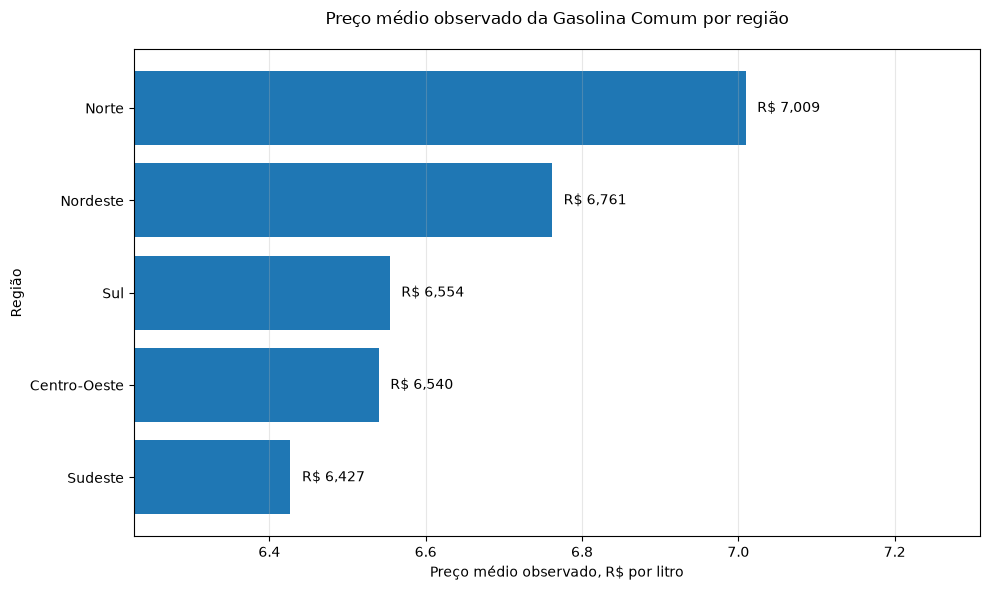

Gráfico salvo em:
c:\Users\jszq\Documents\GitHub\sales-performance-analytics\images\preco_gasolina_por_regiao_2026.png
Arquivo encontrado: True


In [36]:
gasolina_regional_grafico = (
    gasolina_por_regiao_preciso
    .sort_values(
        "preco_medio",
        ascending=True
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(
    gasolina_regional_grafico["regiao"],
    gasolina_regional_grafico["preco_medio"]
)

ax.set_title(
    "Preço médio observado da Gasolina Comum por região",
    pad=18
)

ax.set_xlabel("Preço médio observado, R$ por litro")
ax.set_ylabel("Região")

ax.grid(
    axis="x",
    alpha=0.3
)

preco_minimo_regional = (
    gasolina_regional_grafico["preco_medio"].min()
)

preco_maximo_regional = (
    gasolina_regional_grafico["preco_medio"].max()
)

ax.set_xlim(
    preco_minimo_regional - 0.20,
    preco_maximo_regional + 0.30
)

for barra, preco in zip(
    barras,
    gasolina_regional_grafico["preco_medio"]
):
    ax.text(
        preco + 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"R$ {preco:.3f}".replace(".", ","),
        va="center"
    )

plt.tight_layout()

ARQUIVO_GRAFICO_REGIONAL = (
    PASTA_PROJETO
    / "images"
    / "preco_gasolina_por_regiao_2026.png"
)

fig.savefig(
    ARQUIVO_GRAFICO_REGIONAL,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico salvo em:")
print(ARQUIVO_GRAFICO_REGIONAL)

print(
    "Arquivo encontrado:",
    ARQUIVO_GRAFICO_REGIONAL.exists()
)

## Ranking estadual da Gasolina

Esta análise apresenta o ranking dos preços médios observados da Gasolina Comum nos 27 estados brasileiros durante o primeiro semestre de 2026.

Além do preço médio, serão consideradas a quantidade de registros e a quantidade de revendas pesquisadas, permitindo avaliar a cobertura da amostra em cada estado.

Os resultados representam médias dos registros disponíveis na pesquisa da ANP, sem ponderação por volume comercializado.

In [37]:
ranking_estadual_gasolina = (
    df_gasolina
    .groupby("estado__sigla", as_index=False)
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        preco_mediano=("valor_de_venda", "median"),
        preco_minimo=("valor_de_venda", "min"),
        preco_maximo=("valor_de_venda", "max"),
        desvio_padrao=("valor_de_venda", "std"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique"),
        quantidade_municipios=("municipio", "nunique")
    )
    .sort_values(
        "preco_medio",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_estadual_gasolina["posicao"] = (
    ranking_estadual_gasolina.index + 1
)

ranking_estadual_gasolina = (
    ranking_estadual_gasolina[[
        "posicao",
        "estado__sigla",
        "preco_medio",
        "preco_mediano",
        "preco_minimo",
        "preco_maximo",
        "desvio_padrao",
        "quantidade_registros",
        "quantidade_revendas",
        "quantidade_municipios"
    ]]
)

ranking_estadual_exibicao = (
    ranking_estadual_gasolina.copy()
)

colunas_precos_estaduais = [
    "preco_medio",
    "preco_mediano",
    "preco_minimo",
    "preco_maximo",
    "desvio_padrao"
]

ranking_estadual_exibicao[
    colunas_precos_estaduais
] = (
    ranking_estadual_exibicao[
        colunas_precos_estaduais
    ]
    .round(3)
)

ranking_estadual_exibicao

,posicao,estado__sigla,preco_medio,preco_mediano,preco_minimo,preco_maximo,desvio_padrao,quantidade_registros,quantidade_revendas,quantidade_municipios
0,1,AC,7.479,7.39,6.79,8.50,0.397,299,20,2
1,2,RR,7.440,7.69,6.70,7.90,0.402,350,16,1
2,3,AM,7.305,6.99,6.48,9.29,0.635,1383,92,3
3,4,RO,7.211,7.27,6.48,7.99,0.277,1278,75,6
4,5,BA,7.020,6.99,5.74,8.88,0.510,5789,299,27
5,6,SE,6.953,7.10,6.32,7.69,0.357,956,45,4
6,7,TO,6.924,6.99,5.81,7.89,0.348,844,78,5
7,8,PE,6.844,6.79,5.73,7.99,0.438,4645,257,18
8,9,RN,6.755,6.76,5.59,7.59,0.276,1074,89,4
9,10,CE,6.732,6.74,5.09,7.90,0.368,3372,239,11


In [38]:
print(
    "Estados no ranking:",
    ranking_estadual_gasolina["estado__sigla"].nunique()
)

print(
    "Registros no ranking:",
    ranking_estadual_gasolina["quantidade_registros"].sum()
)

print(
    "Registros de Gasolina:",
    len(df_gasolina)
)

print(
    "Totais são iguais:",
    ranking_estadual_gasolina[
        "quantidade_registros"
    ].sum() == len(df_gasolina)
)

Estados no ranking: 27
Registros no ranking: 110923
Registros de Gasolina: 110923
Totais são iguais: True


In [39]:
top_5_estados = (
    ranking_estadual_gasolina
    .head(5)
    .copy()
)

bottom_5_estados = (
    ranking_estadual_gasolina
    .tail(5)
    .sort_values(
        "preco_medio",
        ascending=True
    )
    .copy()
)

print("Cinco maiores preços médios observados:")
display(
    top_5_estados[[
        "posicao",
        "estado__sigla",
        "preco_medio",
        "quantidade_registros",
        "quantidade_revendas"
    ]]
    .round({
        "preco_medio": 3
    })
)

print("Cinco menores preços médios observados:")
display(
    bottom_5_estados[[
        "posicao",
        "estado__sigla",
        "preco_medio",
        "quantidade_registros",
        "quantidade_revendas"
    ]]
    .round({
        "preco_medio": 3
    })
)

Cinco maiores preços médios observados:


,posicao,estado__sigla,preco_medio,quantidade_registros,quantidade_revendas
0,1,AC,7.479,299,20
1,2,RR,7.440,350,16
2,3,AM,7.305,1383,92
3,4,RO,7.211,1278,75
4,5,BA,7.020,5789,299


Cinco menores preços médios observados:


,posicao,estado__sigla,preco_medio,quantidade_registros,quantidade_revendas
26,27,MG,6.336,11928,752
25,26,PB,6.344,1672,133
24,25,PI,6.396,1388,104
23,24,SP,6.424,30913,2579
22,23,DF,6.434,1247,134


In [40]:
estados_repetidos = set(
    top_5_estados["estado__sigla"]
).intersection(
    set(bottom_5_estados["estado__sigla"])
)

print(
    "Estados repetidos entre os grupos:",
    estados_repetidos
)

print(
    "Quantidade no Top 5:",
    len(top_5_estados)
)

print(
    "Quantidade no Bottom 5:",
    len(bottom_5_estados)
)

Estados repetidos entre os grupos: set()
Quantidade no Top 5: 5
Quantidade no Bottom 5: 5


### Estados com maiores e menores preços médios

A visualização a seguir apresenta os cinco estados com os maiores e os cinco estados com os menores preços médios observados da Gasolina Comum.

A quantidade de registros e de revendas varia entre os estados. Portanto, o ranking deve ser interpretado considerando também a cobertura da pesquisa em cada unidade federativa.

In [41]:
top_5_grafico = (
    top_5_estados
    .sort_values(
        "preco_medio",
        ascending=True
    )
    .copy()
)

bottom_5_grafico = (
    bottom_5_estados
    .sort_values(
        "preco_medio",
        ascending=False
    )
    .copy()
)

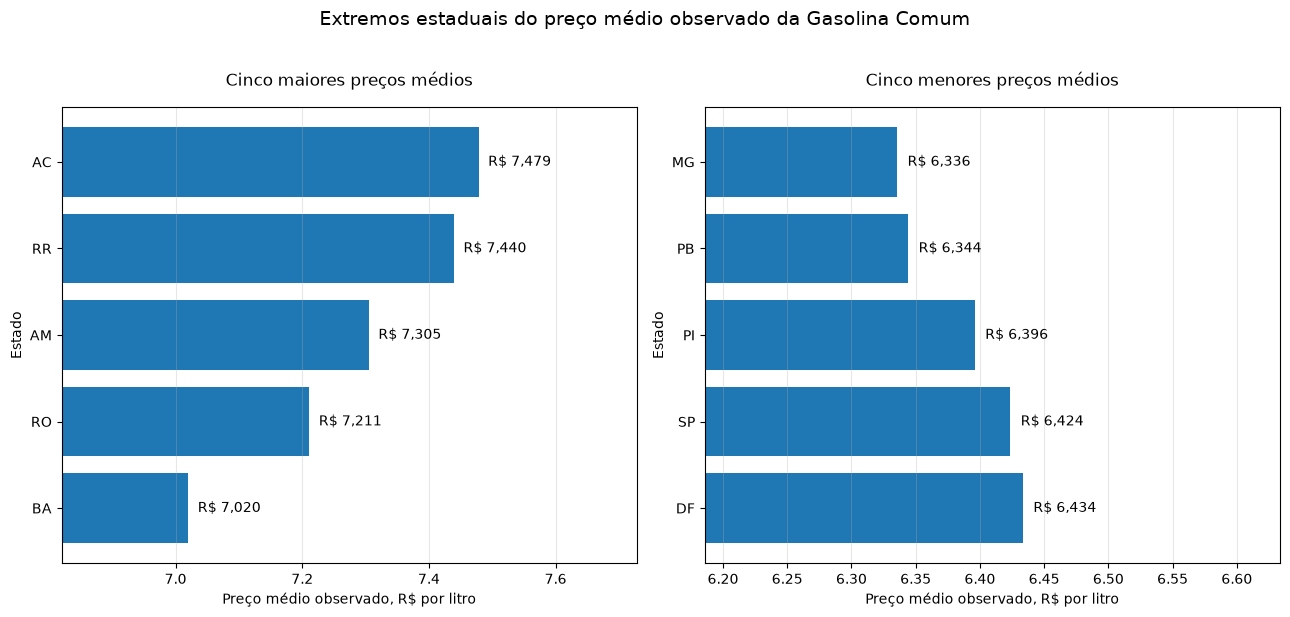

Gráfico salvo em:
c:\Users\jszq\Documents\GitHub\sales-performance-analytics\images\ranking_estadual_gasolina_2026.png
Arquivo encontrado: True


In [42]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 6)
)

# Painel 1: maiores preços

barras_top = ax1.barh(
    top_5_grafico["estado__sigla"],
    top_5_grafico["preco_medio"]
)

ax1.set_title(
    "Cinco maiores preços médios",
    pad=15
)

ax1.set_xlabel("Preço médio observado, R$ por litro")
ax1.set_ylabel("Estado")
ax1.grid(axis="x", alpha=0.3)

menor_top = top_5_grafico["preco_medio"].min()
maior_top = top_5_grafico["preco_medio"].max()

ax1.set_xlim(
    menor_top - 0.20,
    maior_top + 0.25
)

for barra, preco in zip(
    barras_top,
    top_5_grafico["preco_medio"]
):
    ax1.text(
        preco + 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"R$ {preco:.3f}".replace(".", ","),
        va="center"
    )

# Painel 2: menores preços

barras_bottom = ax2.barh(
    bottom_5_grafico["estado__sigla"],
    bottom_5_grafico["preco_medio"]
)

ax2.set_title(
    "Cinco menores preços médios",
    pad=15
)

ax2.set_xlabel("Preço médio observado, R$ por litro")
ax2.set_ylabel("Estado")
ax2.grid(axis="x", alpha=0.3)

menor_bottom = bottom_5_grafico["preco_medio"].min()
maior_bottom = bottom_5_grafico["preco_medio"].max()

ax2.set_xlim(
    menor_bottom - 0.15,
    maior_bottom + 0.20
)

for barra, preco in zip(
    barras_bottom,
    bottom_5_grafico["preco_medio"]
):
    ax2.text(
        preco + 0.008,
        barra.get_y() + barra.get_height() / 2,
        f"R$ {preco:.3f}".replace(".", ","),
        va="center"
    )

fig.suptitle(
    "Extremos estaduais do preço médio observado da Gasolina Comum",
    fontsize=14,
    y=1.02
)

plt.tight_layout()

ARQUIVO_GRAFICO_ESTADUAL = (
    PASTA_PROJETO
    / "images"
    / "ranking_estadual_gasolina_2026.png"
)

fig.savefig(
    ARQUIVO_GRAFICO_ESTADUAL,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico salvo em:")
print(ARQUIVO_GRAFICO_ESTADUAL)

print(
    "Arquivo encontrado:",
    ARQUIVO_GRAFICO_ESTADUAL.exists()
)

## Dispersão dos preços da Gasolina por município

Esta análise identifica os municípios com maior dispersão nos preços observados da Gasolina Comum.

Para reduzir o impacto de amostras muito pequenas, foram considerados apenas municípios com pelo menos 100 registros e 10 revendas distintas no período analisado.

A dispersão será avaliada por meio do desvio-padrão, da amplitude entre os preços mínimo e máximo e do coeficiente de variação.

In [43]:
gasolina_por_municipio = (
    df_gasolina
    .groupby(
        ["estado__sigla", "municipio"],
        as_index=False
    )
    .agg(
        preco_medio=("valor_de_venda", "mean"),
        preco_mediano=("valor_de_venda", "median"),
        preco_minimo=("valor_de_venda", "min"),
        preco_maximo=("valor_de_venda", "max"),
        desvio_padrao=("valor_de_venda", "std"),
        quantidade_registros=("valor_de_venda", "size"),
        quantidade_revendas=("cnpj_da_revenda", "nunique")
    )
)

gasolina_por_municipio["amplitude_preco"] = (
    gasolina_por_municipio["preco_maximo"]
    - gasolina_por_municipio["preco_minimo"]
)

gasolina_por_municipio["coeficiente_variacao"] = (
    gasolina_por_municipio["desvio_padrao"]
    / gasolina_por_municipio["preco_medio"]
    * 100
)

print(
    "Municípios antes do filtro:",
    len(gasolina_por_municipio)
)

Municípios antes do filtro: 417


In [44]:
municipios_elegiveis = (
    gasolina_por_municipio[
        (gasolina_por_municipio["quantidade_registros"] >= 100)
        & (
            gasolina_por_municipio[
                "quantidade_revendas"
            ] >= 10
        )
    ]
    .copy()
)

print(
    "Municípios após o filtro:",
    len(municipios_elegiveis)
)

print(
    "Registros considerados:",
    municipios_elegiveis[
        "quantidade_registros"
    ].sum()
)

Municípios após o filtro: 272
Registros considerados: 88969


In [45]:
ranking_dispersao_municipal = (
    municipios_elegiveis
    .sort_values(
        "desvio_padrao",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_dispersao_municipal["posicao"] = (
    ranking_dispersao_municipal.index + 1
)

ranking_dispersao_exibicao = (
    ranking_dispersao_municipal[[
        "posicao",
        "municipio",
        "estado__sigla",
        "preco_medio",
        "preco_minimo",
        "preco_maximo",
        "amplitude_preco",
        "desvio_padrao",
        "coeficiente_variacao",
        "quantidade_registros",
        "quantidade_revendas"
    ]]
    .head(10)
    .copy()
)

colunas_decimais_municipais = [
    "preco_medio",
    "preco_minimo",
    "preco_maximo",
    "amplitude_preco",
    "desvio_padrao",
    "coeficiente_variacao"
]

ranking_dispersao_exibicao[
    colunas_decimais_municipais
] = (
    ranking_dispersao_exibicao[
        colunas_decimais_municipais
    ]
    .round(3)
)

ranking_dispersao_exibicao

,posicao,municipio,estado__sigla,preco_medio,preco_minimo,preco_maximo,amplitude_preco,desvio_padrao,coeficiente_variacao,quantidade_registros,quantidade_revendas
0,1,GUARUJA,SP,6.936,5.89,9.79,3.90,0.980,14.127,260,16
1,2,BARUERI,SP,6.832,5.59,9.29,3.70,0.861,12.599,350,34
2,3,TABOAO DA SERRA,SP,6.374,5.44,7.99,2.55,0.661,10.363,200,15
3,4,BRUMADO,BA,7.451,6.69,8.07,1.38,0.580,7.778,326,14
4,5,SENHOR DO BONFIM,BA,7.026,5.89,7.79,1.90,0.520,7.396,365,16
5,6,SAO CAETANO DO SUL,SP,6.453,5.39,7.29,1.90,0.472,7.318,286,17
6,7,BRAGANCA,PA,6.785,6.05,7.99,1.94,0.472,6.949,136,12
7,8,SALVADOR,BA,6.703,5.79,7.69,1.90,0.470,7.005,529,27
8,9,ASSIS,SP,6.533,5.49,7.19,1.70,0.464,7.096,260,15
9,10,PRESIDENTE DUTRA,MA,6.535,5.79,7.32,1.53,0.464,7.094,395,19


In [46]:
print(
    "Menor quantidade de registros:",
    municipios_elegiveis[
        "quantidade_registros"
    ].min()
)

print(
    "Menor quantidade de revendas:",
    municipios_elegiveis[
        "quantidade_revendas"
    ].min()
)

print(
    "Existem desvios-padrão nulos:",
    municipios_elegiveis[
        "desvio_padrao"
    ].isna().any()
)

print(
    "Existem amplitudes negativas:",
    (
        municipios_elegiveis[
            "amplitude_preco"
        ] < 0
    ).any()
)

Menor quantidade de registros: 102
Menor quantidade de revendas: 10
Existem desvios-padrão nulos: False
Existem amplitudes negativas: False


### Investigação do município com maior dispersão

Antes de interpretar os resultados do ranking municipal, será analisada a distribuição dos preços no município com o maior desvio-padrão.

O objetivo é verificar se a dispersão está distribuída entre os registros ou concentrada em poucos valores extremos. Nenhum registro será removido nesta etapa.

In [47]:
municipio_maior_dispersao = (
    ranking_dispersao_municipal.iloc[0]
)

municipio_analisado = (
    municipio_maior_dispersao["municipio"]
)

estado_analisado = (
    municipio_maior_dispersao["estado__sigla"]
)

print(
    "Município analisado:",
    municipio_analisado
)

print(
    "Estado:",
    estado_analisado
)

print(
    "Desvio-padrão:",
    round(
        municipio_maior_dispersao["desvio_padrao"],
        3
    )
)

print(
    "Coeficiente de variação:",
    round(
        municipio_maior_dispersao[
            "coeficiente_variacao"
        ],
        3
    ),
    "%"
)

Município analisado: GUARUJA
Estado: SP
Desvio-padrão: 0.98
Coeficiente de variação: 14.127 %


In [48]:
df_municipio_maior_dispersao = (
    df_gasolina[
        (
            df_gasolina["municipio"]
            == municipio_analisado
        )
        & (
            df_gasolina["estado__sigla"]
            == estado_analisado
        )
    ]
    .copy()
)

print(
    "Quantidade de registros:",
    len(df_municipio_maior_dispersao)
)

print(
    "Quantidade de revendas:",
    df_municipio_maior_dispersao[
        "cnpj_da_revenda"
    ].nunique()
)

print(
    "Quantidade de datas de coleta:",
    df_municipio_maior_dispersao[
        "data_da_coleta"
    ].nunique()
)

Quantidade de registros: 260
Quantidade de revendas: 16
Quantidade de datas de coleta: 27


In [49]:
percentis_municipio = (
    df_municipio_maior_dispersao[
        "valor_de_venda"
    ]
    .quantile([
        0.00,
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
        1.00
    ])
    .reset_index()
)

percentis_municipio.columns = [
    "percentil",
    "valor_de_venda"
]

percentis_municipio[
    "percentil"
] = (
    percentis_municipio["percentil"]
    .mul(100)
)

percentis_municipio[
    "valor_de_venda"
] = (
    percentis_municipio["valor_de_venda"]
    .round(3)
)

percentis_municipio

,percentil,valor_de_venda
0,0.0,5.890
1,1.0,5.890
2,5.0,6.050
3,25.0,6.390
4,50.0,6.690
5,75.0,6.890
6,95.0,9.542
7,99.0,9.690
8,100.0,9.790


In [50]:
maiores_precos_municipio = (
    df_municipio_maior_dispersao[[
        "data_da_coleta",
        "revenda",
        "cnpj_da_revenda",
        "valor_de_venda",
        "bandeira"
    ]]
    .sort_values(
        "valor_de_venda",
        ascending=False
    )
    .head(10)
)

maiores_precos_municipio

,data_da_coleta,revenda,cnpj_da_revenda,valor_de_venda,bandeira
419584,2026-06-30,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.79,VIBRA
373732,2026-06-08,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.69,VIBRA
339989,2026-05-25,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.69,VIBRA
323163,2026-05-18,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.69,VIBRA
357063,2026-06-01,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.69,VIBRA
390140,2026-06-16,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.69,VIBRA
406511,2026-06-22,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.69,VIBRA
228480,2026-04-06,GDO PARTICIPACOES S/A,27.751.075/0016-47,9.59,VIBRA
290089,2026-05-04,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.59,VIBRA
306532,2026-05-11,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,18.018.790/0001-06,9.59,VIBRA


In [51]:
frequencia_precos_municipio = (
    df_municipio_maior_dispersao[
        "valor_de_venda"
    ]
    .value_counts()
    .rename_axis("valor_de_venda")
    .reset_index(name="quantidade")
    .sort_values(
        ["quantidade", "valor_de_venda"],
        ascending=[False, True]
    )
    .head(15)
)

frequencia_precos_municipio

,valor_de_venda,quantidade
0,6.69,50
1,6.79,24
2,6.59,23
3,6.39,22
4,6.29,17
5,6.89,17
6,9.29,14
7,6.05,10
8,6.75,9
9,7.09,7


### Comparação dos indicadores de dispersão

O desvio-padrão mede a dispersão dos preços em valores absolutos, enquanto o coeficiente de variação relaciona o desvio-padrão ao preço médio de cada município.

Para definir o indicador principal da visualização, serão comparados os dez municípios mais dispersos segundo cada uma das duas métricas.

In [53]:
top_10_desvio_padrao = (
    municipios_elegiveis
    .sort_values(
        "desvio_padrao",
        ascending=False
    )
    .head(10)
    .copy()
)

top_10_desvio_padrao["ranking_desvio"] = range(
    1,
    len(top_10_desvio_padrao) + 1
)

top_10_desvio_padrao[[
    "ranking_desvio",
    "municipio",
    "estado__sigla",
    "preco_medio",
    "desvio_padrao",
    "coeficiente_variacao",
    "quantidade_registros",
    "quantidade_revendas"
]].round(3)

,ranking_desvio,municipio,estado__sigla,preco_medio,desvio_padrao,coeficiente_variacao,quantidade_registros,quantidade_revendas
341,1,GUARUJA,SP,6.936,0.980,14.127,260,16
321,2,BARUERI,SP,6.832,0.861,12.599,350,34
402,3,TABOAO DA SERRA,SP,6.374,0.661,10.363,200,15
14,4,BRUMADO,BA,7.451,0.580,7.778,326,14
34,5,SENHOR DO BONFIM,BA,7.026,0.520,7.396,365,16
391,6,SAO CAETANO DO SUL,SP,6.453,0.472,7.318,286,17
158,7,BRAGANCA,PA,6.785,0.472,6.949,136,12
32,8,SALVADOR,BA,6.703,0.470,7.005,529,27
317,9,ASSIS,SP,6.533,0.464,7.096,260,15
84,10,PRESIDENTE DUTRA,MA,6.535,0.464,7.094,395,19


In [54]:
top_10_coeficiente_variacao = (
    municipios_elegiveis
    .sort_values(
        "coeficiente_variacao",
        ascending=False
    )
    .head(10)
    .copy()
)

top_10_coeficiente_variacao[
    "ranking_coeficiente"
] = range(
    1,
    len(top_10_coeficiente_variacao) + 1
)

top_10_coeficiente_variacao[[
    "ranking_coeficiente",
    "municipio",
    "estado__sigla",
    "preco_medio",
    "desvio_padrao",
    "coeficiente_variacao",
    "quantidade_registros",
    "quantidade_revendas"
]].round(3)

,ranking_coeficiente,municipio,estado__sigla,preco_medio,desvio_padrao,coeficiente_variacao,quantidade_registros,quantidade_revendas
341,1,GUARUJA,SP,6.936,0.980,14.127,260,16
321,2,BARUERI,SP,6.832,0.861,12.599,350,34
402,3,TABOAO DA SERRA,SP,6.374,0.661,10.363,200,15
14,4,BRUMADO,BA,7.451,0.580,7.778,326,14
34,5,SENHOR DO BONFIM,BA,7.026,0.520,7.396,365,16
391,6,SAO CAETANO DO SUL,SP,6.453,0.472,7.318,286,17
317,7,ASSIS,SP,6.533,0.464,7.096,260,15
84,8,PRESIDENTE DUTRA,MA,6.535,0.464,7.094,395,19
32,9,SALVADOR,BA,6.703,0.470,7.005,529,27
17,10,FEIRA DE SANTANA,BA,6.628,0.463,6.988,369,29


In [55]:
municipios_ranking_desvio = set(
    zip(
        top_10_desvio_padrao["estado__sigla"],
        top_10_desvio_padrao["municipio"]
    )
)

municipios_ranking_coeficiente = set(
    zip(
        top_10_coeficiente_variacao[
            "estado__sigla"
        ],
        top_10_coeficiente_variacao[
            "municipio"
        ]
    )
)

municipios_em_comum = (
    municipios_ranking_desvio
    .intersection(
        municipios_ranking_coeficiente
    )
)

print(
    "Municípios presentes nos dois rankings:",
    len(municipios_em_comum)
)

print(
    "Municípios exclusivos do ranking por desvio-padrão:",
    municipios_ranking_desvio
    - municipios_ranking_coeficiente
)

print(
    "Municípios exclusivos do ranking por coeficiente de variação:",
    municipios_ranking_coeficiente
    - municipios_ranking_desvio
)

Municípios presentes nos dois rankings: 9
Municípios exclusivos do ranking por desvio-padrão: {('PA', 'BRAGANCA')}
Municípios exclusivos do ranking por coeficiente de variação: {('BA', 'FEIRA DE SANTANA')}


### Definição do indicador de dispersão

Os rankings por desvio-padrão e coeficiente de variação apresentaram nove municípios em comum entre as dez primeiras posições.

Guarujá, Barueri e Taboão da Serra permaneceram nas três primeiras posições nos dois métodos, indicando que a elevada dispersão observada nesses municípios não depende exclusivamente do indicador escolhido.

Para a visualização principal, foi adotado o coeficiente de variação, pois esse indicador relaciona o desvio-padrão ao preço médio de cada município e permite uma comparação proporcional entre localidades com diferentes níveis de preço.

O desvio-padrão e a amplitude permanecerão disponíveis como indicadores complementares.

A análise considera somente municípios com pelo menos 100 registros e 10 revendas distintas durante o período.

In [56]:
municipios_cv_grafico = (
    top_10_coeficiente_variacao
    .sort_values(
        "coeficiente_variacao",
        ascending=True
    )
    .copy()
)

municipios_cv_grafico["municipio_uf"] = (
    municipios_cv_grafico["municipio"]
    .str.title()
    + " / "
    + municipios_cv_grafico["estado__sigla"]
)

municipios_cv_grafico[[
    "municipio_uf",
    "preco_medio",
    "desvio_padrao",
    "coeficiente_variacao",
    "quantidade_registros",
    "quantidade_revendas"
]]

,municipio_uf,preco_medio,desvio_padrao,coeficiente_variacao,quantidade_registros,quantidade_revendas
17,Feira De Santana / BA,6.628184,0.463199,6.988327,369,29
32,Salvador / BA,6.703384,0.469597,7.005366,529,27
84,Presidente Dutra / MA,6.534785,0.463558,7.093698,395,19
317,Assis / SP,6.532731,0.463582,7.096305,260,15
391,Sao Caetano Do Sul / SP,6.453322,0.472247,7.317892,286,17
34,Senhor Do Bonfim / BA,7.025671,0.519646,7.396394,365,16
14,Brumado / BA,7.451074,0.579544,7.777992,326,14
402,Taboao Da Serra / SP,6.374250,0.660551,10.362809,200,15
321,Barueri / SP,6.831514,0.860681,12.598679,350,34
341,Guaruja / SP,6.936346,0.979902,14.127062,260,16


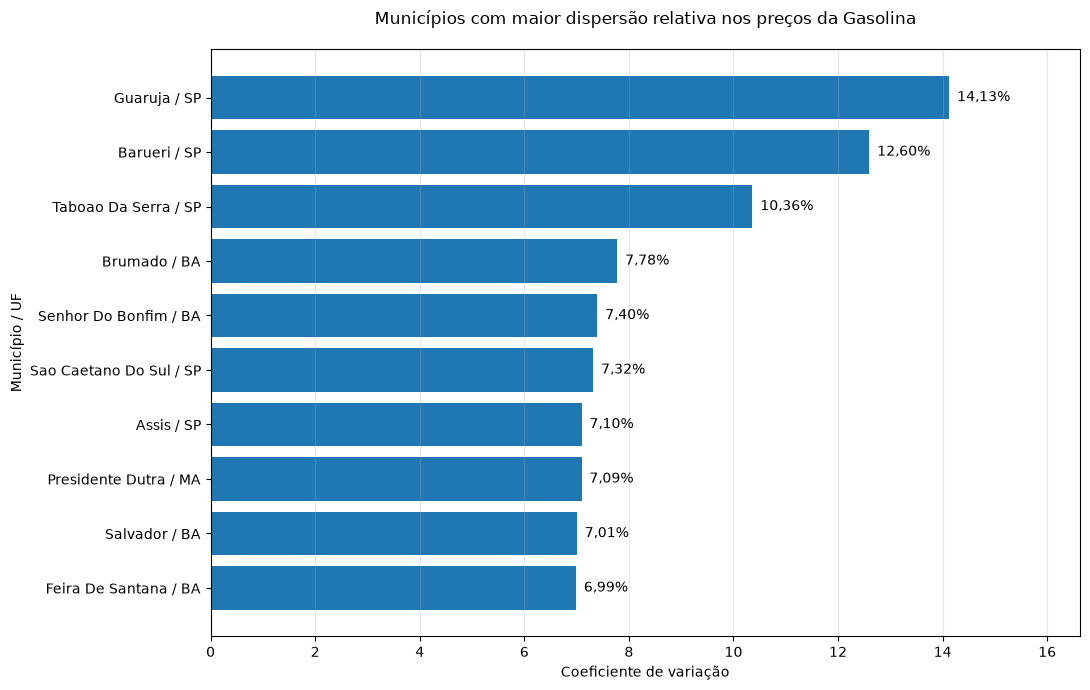

Gráfico salvo em:
c:\Users\jszq\Documents\GitHub\sales-performance-analytics\images\dispersao_municipal_gasolina_2026.png
Arquivo encontrado: True


In [57]:
fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    municipios_cv_grafico["municipio_uf"],
    municipios_cv_grafico["coeficiente_variacao"]
)

ax.set_title(
    "Municípios com maior dispersão relativa nos preços da Gasolina",
    pad=18
)

ax.set_xlabel("Coeficiente de variação")
ax.set_ylabel("Município / UF")

ax.grid(
    axis="x",
    alpha=0.3
)

maior_coeficiente = (
    municipios_cv_grafico[
        "coeficiente_variacao"
    ].max()
)

ax.set_xlim(
    0,
    maior_coeficiente + 2.5
)

for barra, coeficiente in zip(
    barras,
    municipios_cv_grafico["coeficiente_variacao"]
):
    ax.text(
        coeficiente + 0.15,
        barra.get_y() + barra.get_height() / 2,
        f"{coeficiente:.2f}%".replace(".", ","),
        va="center"
    )

plt.tight_layout()

ARQUIVO_GRAFICO_DISPERSAO = (
    PASTA_PROJETO
    / "images"
    / "dispersao_municipal_gasolina_2026.png"
)

fig.savefig(
    ARQUIVO_GRAFICO_DISPERSAO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico salvo em:")
print(ARQUIVO_GRAFICO_DISPERSAO)

print(
    "Arquivo encontrado:",
    ARQUIVO_GRAFICO_DISPERSAO.exists()
)

## Exportação das tabelas analíticas

As tabelas analíticas construídas e validadas serão exportadas para a pasta `data/processed`.

Esses arquivos serão utilizados como apoio na documentação e na construção do dashboard no Power BI.

A base tratada detalhada continuará sendo a principal fonte de dados do dashboard.

In [60]:
PASTA_ANALYTICS = (
    PASTA_PROCESSED
    / "analytics"
)

PASTA_ANALYTICS.mkdir(
    parents=True,
    exist_ok=True
)

print("Pasta criada:")
print(PASTA_ANALYTICS)

print(
    "Pasta encontrada:",
    PASTA_ANALYTICS.exists()
)

Pasta criada:
c:\Users\jszq\Documents\GitHub\sales-performance-analytics\data\processed\analytics
Pasta encontrada: True


In [61]:
tabelas_analytics = {
    "resumo_executivo.csv": resumo_executivo,
    "preco_medio_por_produto.csv": preco_medio_produto,
    "gasolina_mensal.csv": gasolina_mensal_grafico,
    "comparacao_gasolina_etanol.csv": precos_gasolina_etanol,
    "gasolina_por_regiao.csv": gasolina_por_regiao_preciso,
    "ranking_estadual_gasolina.csv": ranking_estadual_gasolina,
    "dispersao_municipal_gasolina.csv": municipios_elegiveis
}

print(
    "Quantidade de tabelas preparadas:",
    len(tabelas_analytics)
)

for nome_arquivo, tabela in tabelas_analytics.items():
    print(
        nome_arquivo,
        tabela.shape
    )

Quantidade de tabelas preparadas: 7
resumo_executivo.csv (7, 2)
preco_medio_por_produto.csv (6, 2)
gasolina_mensal.csv (6, 6)
comparacao_gasolina_etanol.csv (6, 7)
gasolina_por_regiao.csv (5, 6)
ranking_estadual_gasolina.csv (27, 10)
dispersao_municipal_gasolina.csv (272, 11)


In [62]:
for nome_arquivo, tabela in tabelas_analytics.items():
    caminho_saida = (
        PASTA_ANALYTICS
        / nome_arquivo
    )

    tabela.to_csv(
        caminho_saida,
        index=False,
        sep=";",
        encoding="utf-8-sig",
        decimal=","
    )

print(
    "Tabelas exportadas com sucesso."
)

Tabelas exportadas com sucesso.


In [63]:
arquivos_gerados = sorted(
    PASTA_ANALYTICS.glob("*.csv")
)

print(
    "Quantidade de arquivos encontrados:",
    len(arquivos_gerados)
)

for arquivo in arquivos_gerados:
    print(
        arquivo.name,
        "|",
        round(
            arquivo.stat().st_size / 1024,
            2
        ),
        "KB"
    )

Quantidade de arquivos encontrados: 7
comparacao_gasolina_etanol.csv | 0.59 KB
dispersao_municipal_gasolina.csv | 29.06 KB
gasolina_mensal.csv | 0.31 KB
gasolina_por_regiao.csv | 0.38 KB
preco_medio_por_produto.csv | 0.12 KB
ranking_estadual_gasolina.csv | 2.0 KB
resumo_executivo.csv | 0.12 KB
